# PageRank Algorithm from Scratch 🌐

## 🌐 Theoretical Background
PageRank measures the importance of website pages. It assumes that more important websites are likely to receive more links from other websites.
- **Damping Factor (d)**: Probability that a random surfer continues clicking.
- **Power Method**: Iterative calculation of the principal eigenvector of the transition matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:

# Transition Matrix (4 pages)
# A linked to B, C; B linked to C; C linked to A; D linked to C
M = np.array([
    [0, 0, 1, 0],
    [0.5, 0, 0, 0],
    [0.5, 1, 0, 1],
    [0, 0, 0, 0]
])

def pagerank(M, num_iterations: int = 100, d: float = 0.85):
    N = M.shape[1]
    v = np.ones(N) / N
    M_hat = d * M + (1 - d) / N * np.ones((N, N))
    for i in range(num_iterations):
        v = M_hat @ v
    return v

scores = pagerank(M)
print(f"PageRank Scores: {scores}")


### 📊 Visualization: Network Graph

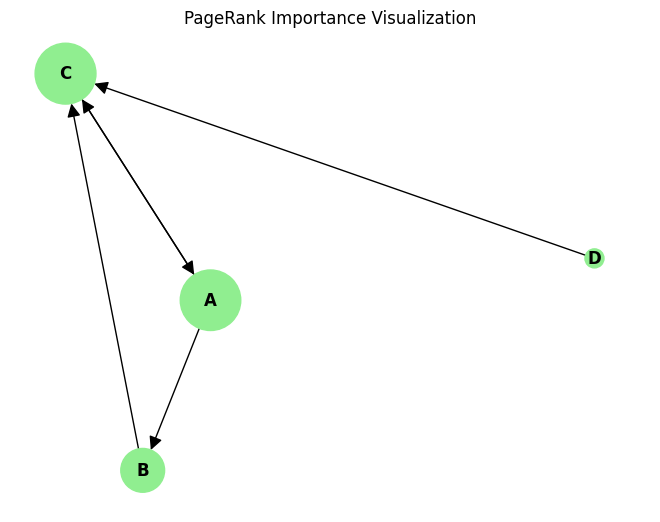

In [3]:

G = nx.DiGraph()
edges = [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('D', 'C')]
G.add_edges_from(edges)
pos = nx.spring_layout(G)
node_sizes = [scores[i]*5000 for i in range(len(scores))]
nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color='lightgreen', font_weight='bold', arrowsize=20)
plt.title("PageRank Importance Visualization")
plt.show()
